#### 0) Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from pathlib import Path

#### 1) Configurations

In [2]:
output_dir_str = r"C:/Users/Hassa/OneDrive - Loughborough University/current/Algorithmic Trading for Beginners/Backtesting Trading Strategies/Data/Processed"
output_dir = Path(output_dir_str)

# Using a highly liquid asset as the optimization baseline to speed up processing
target_ticker = "AAPL"

#### 2) Fast Simulator and Data Splitting

In [6]:
df_raw = pd.read_parquet(output_dir / f"signals_{target_ticker}.parquet")

# Split data 70 percent In Sample and 30 percent Out of Sample
split_idx = int(len(df_raw) * 0.70)
df_is = df_raw.iloc[:split_idx].copy()
df_oos = df_raw.iloc[split_idx:].copy()

def fast_grid_simulator(df, short_ma, long_ma, sl_pct=None, tp_pct=None):
    close = df['Close']
    sma_s = close.rolling(short_ma).mean()
    sma_l = close.rolling(long_ma).mean()
    
    # 1 for long and 0 for cash, explicitly keeping the Date index
    signal = pd.Series(np.where(sma_s > sma_l, 1, 0), index=close.index)
    signal = signal.shift(1).fillna(0)
    
    daily_ret = close.pct_change().fillna(0)
    strat_ret = daily_ret * signal
    
    # Apply Stop Loss and Take Profit using pandas clip to preserve index
    if tp_pct is not None or sl_pct is not None:
        strat_ret = strat_ret.clip(
            lower=-sl_pct if sl_pct is not None else None, 
            upper=tp_pct if tp_pct is not None else None
        )
        
    # Calculate Sharpe
    excess_ret = strat_ret
    sharpe = (excess_ret.mean() / excess_ret.std()) * np.sqrt(252) if excess_ret.std() > 0 else 0
    
    # Calculate Calmar
    cum_ret = (1 + strat_ret).cumprod()
    rolling_max = cum_ret.cummax()
    drawdown = (cum_ret - rolling_max) / rolling_max
    max_dd = abs(drawdown.min())
    
    ann_ret = (1 + strat_ret.mean()) ** 252 - 1
    calmar = ann_ret / max_dd if max_dd > 0 else 0
    
    return sharpe, calmar

print(f"Data split complete. In Sample rows: {len(df_is)}. Out of Sample rows: {len(df_oos)}.")

Data split complete. In Sample rows: 2816. Out of Sample rows: 1207.


#### 3) MA window Grid Search

In [7]:
short_mas = [5, 9, 12, 15, 20]
long_mas = [21, 50, 100, 150, 200]

ma_results = []

print("Running Moving Average Parameter Grid Search")
for sma, lma in product(short_mas, long_mas):
    if sma >= lma:
        continue
        
    sharpe, calmar = fast_grid_simulator(df_is, sma, lma)
    
    ma_results.append({
        "Short_MA": sma,
        "Long_MA": lma,
        "Sharpe": sharpe,
        "Calmar": calmar
    })

df_ma_opt = pd.DataFrame(ma_results)
print("MA Grid Search Complete")

Running Moving Average Parameter Grid Search
MA Grid Search Complete


#### 4) MA Parameter Heatmaps 

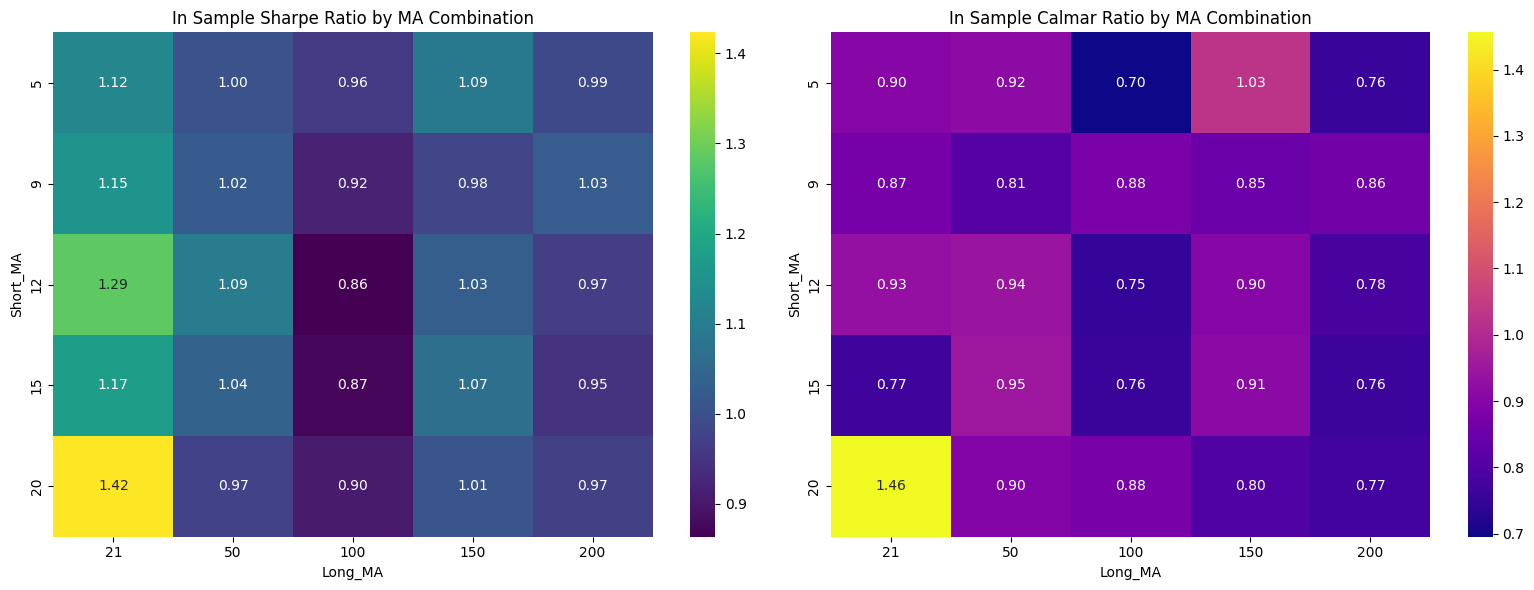

CRITICAL OVERFITTING DISCLAIMER
These heatmaps represent historical optimization on the In Sample dataset only.
Selecting the absolute maximum cell guarantees curve fitting to past market noise.
Look for broad clusters of stability rather than isolated peaks.
Always validate the chosen parameters on a holdout walk forward split.


In [8]:
sharpe_pivot = df_ma_opt.pivot(index="Short_MA", columns="Long_MA", values="Sharpe")
calmar_pivot = df_ma_opt.pivot(index="Short_MA", columns="Long_MA", values="Calmar")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(sharpe_pivot, annot=True, fmt=".2f", cmap="viridis", ax=axes[0])
axes[0].set_title("In Sample Sharpe Ratio by MA Combination")

sns.heatmap(calmar_pivot, annot=True, fmt=".2f", cmap="plasma", ax=axes[1])
axes[1].set_title("In Sample Calmar Ratio by MA Combination")

plt.tight_layout()
plt.show()

print("CRITICAL OVERFITTING DISCLAIMER")
print("These heatmaps represent historical optimization on the In Sample dataset only.")
print("Selecting the absolute maximum cell guarantees curve fitting to past market noise.")
print("Look for broad clusters of stability rather than isolated peaks.")
print("Always validate the chosen parameters on a holdout walk forward split.")

#### SL & TP Grid Search

Running SL and TP Grid Search using MA 9 and 21


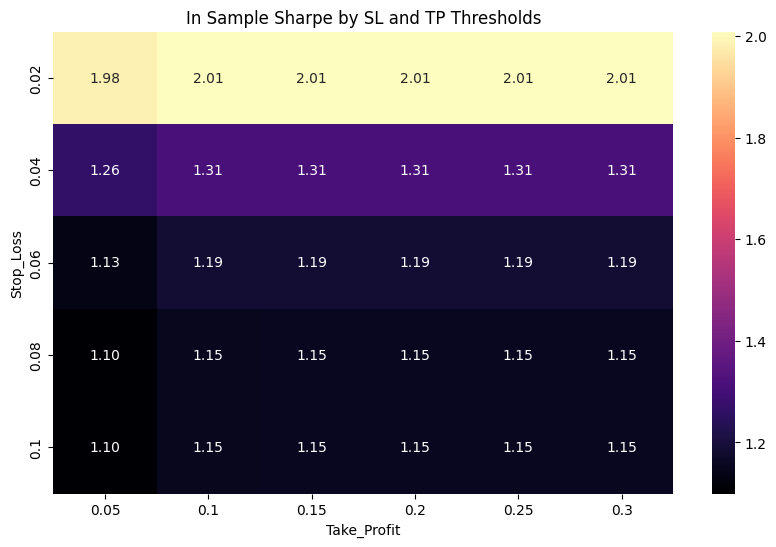

In [9]:
chosen_short = 9
chosen_long = 21

sl_levels = [0.02, 0.04, 0.06, 0.08, 0.10]
tp_levels = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

sltp_results = []

print(f"Running SL and TP Grid Search using MA {chosen_short} and {chosen_long}")
for sl, tp in product(sl_levels, tp_levels):
    sharpe, calmar = fast_grid_simulator(df_is, chosen_short, chosen_long, sl, tp)
    
    sltp_results.append({
        "Stop_Loss": sl,
        "Take_Profit": tp,
        "Sharpe": sharpe,
        "Calmar": calmar
    })

df_sltp_opt = pd.DataFrame(sltp_results)
sltp_pivot = df_sltp_opt.pivot(index="Stop_Loss", columns="Take_Profit", values="Sharpe")

plt.figure(figsize=(10, 6))
sns.heatmap(sltp_pivot, annot=True, fmt=".2f", cmap="magma")
plt.title("In Sample Sharpe by SL and TP Thresholds")
plt.show()

#### 6) Walk Forward Overfitting Test

In [10]:
# Extract the mathematically optimal parameters from the In Sample training grid
best_row = df_sltp_opt.loc[df_sltp_opt['Sharpe'].idxmax()]
best_sl = best_row['Stop_Loss']
best_tp = best_row['Take_Profit']

print(f"Optimal Grid Parameters Found: Stop Loss {best_sl}, Take Profit {best_tp}")

# Validate In Sample Performance
is_sharpe, is_calmar = fast_grid_simulator(df_is, chosen_short, chosen_long, best_sl, best_tp)

# Test Out of Sample Performance
oos_sharpe, oos_calmar = fast_grid_simulator(df_oos, chosen_short, chosen_long, best_sl, best_tp)

print("Robustness and Overfitting Test Results")
print(f"In Sample Sharpe: {is_sharpe:.2f}")
print(f"Out of Sample Sharpe: {oos_sharpe:.2f}")

degradation = (is_sharpe - oos_sharpe) / is_sharpe if is_sharpe > 0 else 0
print(f"Sharpe Ratio Degradation: {degradation:.2%}")

if degradation > 0.40:
    print("WARNING: Severe degradation detected. The strategy parameters are highly overfit to the training period.")
elif degradation > 0:
    print("Normal degradation detected. The strategy parameters maintain some edge on unseen data.")
else:
    print("Out of Sample performance exceeded In Sample. This indicates extreme robustness or a favorable regime shift.")

Optimal Grid Parameters Found: Stop Loss 0.02, Take Profit 0.1
Robustness and Overfitting Test Results
In Sample Sharpe: 2.01
Out of Sample Sharpe: 1.03
Sharpe Ratio Degradation: 48.57%


#### Export Results

In [11]:
df_ma_opt.to_parquet(output_dir / "optimization_ma_results.parquet")
df_sltp_opt.to_parquet(output_dir / "optimization_sltp_results.parquet")

print("Optimization tables saved successfully.")

Optimization tables saved successfully.
